In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

import ipywidgets as widgets
from IPython.display import display
import trimesh



In [2]:

def cox_de_boor(x, knots, degree, i):
	"""
	Compute the value of the i-th B-spline basis function of given degree at x using the Cox-de Boor recursion formula.
	
	Parameters:
	x (torch.Tensor): The input value(s) where the B-spline is evaluated.
	knots (torch.Tensor): The knot sequence.
	degree (int): The degree of the B-spline.
	i (int): The index of the basis function.
	
	Returns:
	torch.Tensor: The value of the basis function at x.
	"""

	if degree == 0:
		return ((knots[i] <= x) & (x < knots[i + 1]) ).float()
	
	denom1 = knots[i + degree] - knots[i]
	denom2 = knots[i + degree + 1] - knots[i + 1]
	
	term1 = 0 if denom1 == 0 else ((x - knots[i]) / denom1) * cox_de_boor(x, knots, degree - 1, i)
	term2 = 0 if denom2 == 0 else ((knots[i + degree + 1] - x) / denom2) * cox_de_boor(x, knots, degree - 1, i + 1)
	
	return term1 + term2


def wrapped_cox_de_boor(x,knots, degree, i):
	return torch.maximum( torch.maximum(cox_de_boor(x,knots, degree, i), cox_de_boor(x+(2*torch.pi),knots, degree, i)), cox_de_boor(x-(2*torch.pi),knots, degree, i))




def parametrise(theta, mesh_path):

    
    tm = trimesh.load(mesh_path)
    V = torch.tensor(tm.vertices, dtype=torch.float)  # Ensure V is a tensor

    i = (V.shape[0] - 1) * (theta / (2 * torch.pi))
    t, i = torch.frac(i), torch.floor(i).long()  # Use torch.frac() for fractional part

    # Ensure i+1 remains within bounds
    i_next = (i + 1) % V.shape[0]

    out = V[i, :2].squeeze() * (1 - t) + V[i_next, :2].squeeze() * t
    #plt.scatter(V[:,0], V[:,1])
    #plt.show()

    return out



class MLP(nn.Module):
	def __init__(self, layer_sizes):
		super(MLP, self).__init__()
		layers = []
		for i in range(len(layer_sizes) - 1):
			layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
			if i < len(layer_sizes) - 2:  # No activation on last layer
				layers.append(nn.Tanh())
		self.network = nn.Sequential(*layers)
	
	def forward(self, x):
		return self.network(x)

class BlendedMLP(nn.Module):
    def __init__(self, n, layer_sizes, degree, knots):
        super(BlendedMLP, self).__init__()
        self.mlps = nn.ModuleList([MLP(layer_sizes) for _ in range(n)])
        self.n = n
        self.degree = degree
        self.knots = knots
        self.wrapped_knots = torch.cat([self.knots, self.knots[0:] + 2 * torch.pi])
        print(self.wrapped_knots)
        self.knot_positions = []

        self.fake_mlps = [lambda x: (torch.rand(1) + torch.sin(5*x)+2)*torch.stack([torch.cos(x), torch.sin(x)]).squeeze().transpose(0,1) for _ in range(n)]

        x = torch.arange(0, 2*torch.pi, 0.001)

        for i in range(n):
            plt.plot(x, wrapped_cox_de_boor(x, self.wrapped_knots[i : i + self.degree + 2], self.degree, 0))
        
        y = torch.tensor([0] * len(knots))
        plt.scatter(knots, y)
        plt.show()

    def component(self, x, i, weight=1):
        
        return (weight * self.mlps[i](torch.stack([torch.sin(x), torch.cos(x)]).squeeze().transpose(0,1)) +
                self.knot_positions[(i+(1+self.degree)//2)%self.n]) * wrapped_cox_de_boor(x - self.wrapped_knots[i], self.wrapped_knots[i:i+self.degree+2] - self.wrapped_knots[i], self.degree, 0)
        
        #return (weight * self.mlps[i](torch.stack([torch.sin(x), torch.cos(x)]).squeeze().transpose(0,1)) +
        #        torch.stack([torch.sin(x), torch.cos(x)]).squeeze().transpose(0,1)) * wrapped_cox_de_boor(x - self.wrapped_knots[i], self.wrapped_knots[i:i+self.degree+2] - self.wrapped_knots[i], self.degree, 0)
        
    def forward(self, x):
        return sum(
            self.component(x,i)
            for i in range(self.n)
        )
    

tensor([ 0.0000,  0.6283,  1.2566,  1.8850,  2.5133,  3.1416,  3.7699,  4.3982,
         5.0265,  5.6549,  6.2832,  6.9115,  7.5398,  8.1681,  8.7965,  9.4248,
        10.0531, 10.6814, 11.3097, 11.9381])


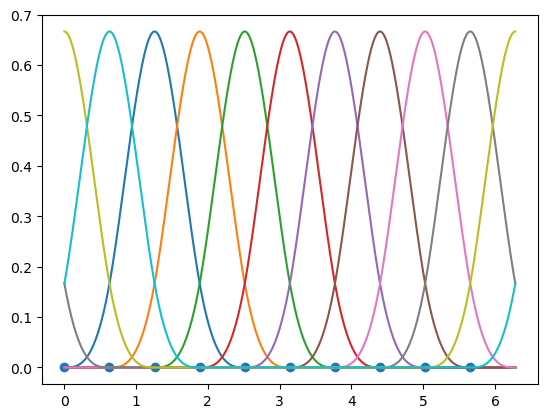

torch.Size([10000, 1])
torch.Size([10000, 2])


In [3]:
	   
# Example usage

layer_sizes = [2, 16, 16, 2]  # Example structure: 1 input, two hidden layers (16 neurons), 1 output
degree=3
#knots = torch.tensor([0,0.5,1.0, 1.7,3.0, 4.2, 5.0, 5.8])
knots = 2*torch.pi * torch.arange(0,1.0,0.1)
n = len(knots)  # Number of MLPs


blended_mlp = BlendedMLP(n, layer_sizes, degree, knots = knots)

#f = lambda theta: torch.stack([torch.cos(theta), torch.sin(theta)]).squeeze().transpose(0,1)
#f = lambda theta: torch.stack([torch.cos(theta), torch.sin(theta)]).squeeze().transpose(0,1) * (1+ 0.1*torch.sin(10*theta))


def f(theta):
    return parametrise(theta, mesh_path="meshes/eagle_bdry.obj")
    
blended_mlp.knot_positions = [f(2*torch.pi* torch.tensor(i/blended_mlp.n)) for i in range(blended_mlp.n)]



# Training all models jointly
optimizer = optim.Adam(blended_mlp.parameters(), lr=0.01)
criterion = nn.MSELoss()

# Dummy training data
theta_train = 2 * torch.pi * torch.rand(10000, 1)
target_train = f(theta_train)


print(theta_train.shape)
print(target_train.shape)







In [4]:

def update_plot( **slider_values ):
    theta = 2 * torch.pi * torch.arange(0, 1.001, 0.001).unsqueeze(-1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Extract weights from slider values
    weights = [slider_values[f'weight_{i}'] for i in range(blended_mlp.n)]

    knot_components = []
    components = []
    for i in range(blended_mlp.n):
        component =  blended_mlp.component(theta, i=i, weight=weights[i])
        axes[0].plot(component.detach()[:, 0], component.detach()[:, 1], linewidth=1, label=f"Comp. {i}", alpha=0.9)
        components.append(component)

        knot_components.append( blended_mlp.component(blended_mlp.knots.unsqueeze(-1), i=i, weight=weights[i]))

    target = f(theta)
    output = sum(components)
    output_knots = sum(knot_components)
   
    axes[0].legend()
    axes[0].set_xlim([-1.2, 1.2])
    axes[0].set_ylim([-1.2, 1.2])
    axes[0].set_title("Components")


    axes[0].plot(output.detach()[:, 0], output.detach()[:, 1], color='blue', linewidth=1, alpha=0.1)
    #axes[0].scatter(output_knots.detach()[:,0], output_knots.detach()[:,1], color='blue', alpha=0.2, s=100.0)
    #for i, (x, y) in enumerate(output_knots.detach()):
    #    axes[1].text(x, y, str(i), fontsize=12, ha='right', va='bottom', color='black')

        

    

    axes[1].plot(target.detach()[:, 0], target.detach()[:, 1], color='red', linewidth=1, alpha=0.5)
    axes[1].plot(output.detach()[:, 0], output.detach()[:, 1], color='blue', linewidth=1, alpha=1.0)
    axes[1].scatter(output_knots.detach()[:,0], output_knots.detach()[:,1], color='blue', alpha=0.2, s=100.0)
    for i, (x, y) in enumerate(output_knots.detach()):
        axes[1].text(x, y, str(i), fontsize=12, ha='right', va='bottom', color='black')
    
    axes[1].set_title("Combined Shape")
    axes[1].axis("equal")
    axes[1].set_xlim([-1.2, 1.2])
    axes[1].set_ylim([-1.2, 1.2])

    plt.show()


def show():
    # Generate sliders for each weight
    weight_sliders = {
        f'weight_{i}': widgets.FloatSlider(min=0, max=1, step=0.1, value=1, description=f"W{i}") for i in range(blended_mlp.n)
    }
    
    # Create interactive widget with all sliders
    interactive_plot = widgets.interactive(update_plot, **weight_sliders)
    
    # Display sliders and plot
    display(interactive_plot)

In [5]:
show()

interactive(children=(FloatSlider(value=1.0, description='W0', max=1.0), FloatSlider(value=1.0, description='W…

In [6]:
epoch=0

In [7]:

# Training loop
for _ in range(1000):
    optimizer.zero_grad()
    output_train = blended_mlp(theta_train)
    loss = criterion(output_train, target_train)
    loss.backward()
    optimizer.step()

    # Corrected indentation for if condition
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")
    
    epoch += 1  # Increment epoch counter


Epoch 0, Loss: 0.0539
Epoch 100, Loss: 0.0029
Epoch 200, Loss: 0.0023
Epoch 300, Loss: 0.0019
Epoch 400, Loss: 0.0017
Epoch 500, Loss: 0.0015
Epoch 600, Loss: 0.0014
Epoch 700, Loss: 0.0012
Epoch 800, Loss: 0.0011
Epoch 900, Loss: 0.0010


In [8]:
show()

interactive(children=(FloatSlider(value=1.0, description='W0', max=1.0), FloatSlider(value=1.0, description='W…